In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path('../data/2nd_test')
files = sorted([f for f in DATA_DIR.iterdir() if f.is_file() and not f.name.startswith('.')])

In [11]:
cols = ['B1', 'B2', 'B3', 'B4']

def read_single(file):
    df = pd.read_csv(file, sep='\t', header=None, names=cols)
    return df

df_healthy = read_single(files[0])
df_broken = read_single(files[-10])

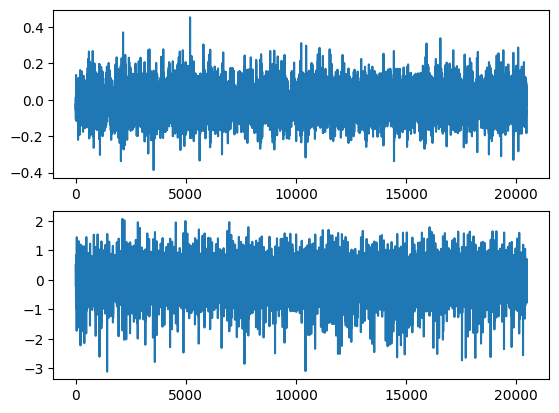

In [12]:
fig, axs = plt.subplots(2)
axs[0].plot(df_healthy['B1'])
axs[1].plot(df_broken['B1'])

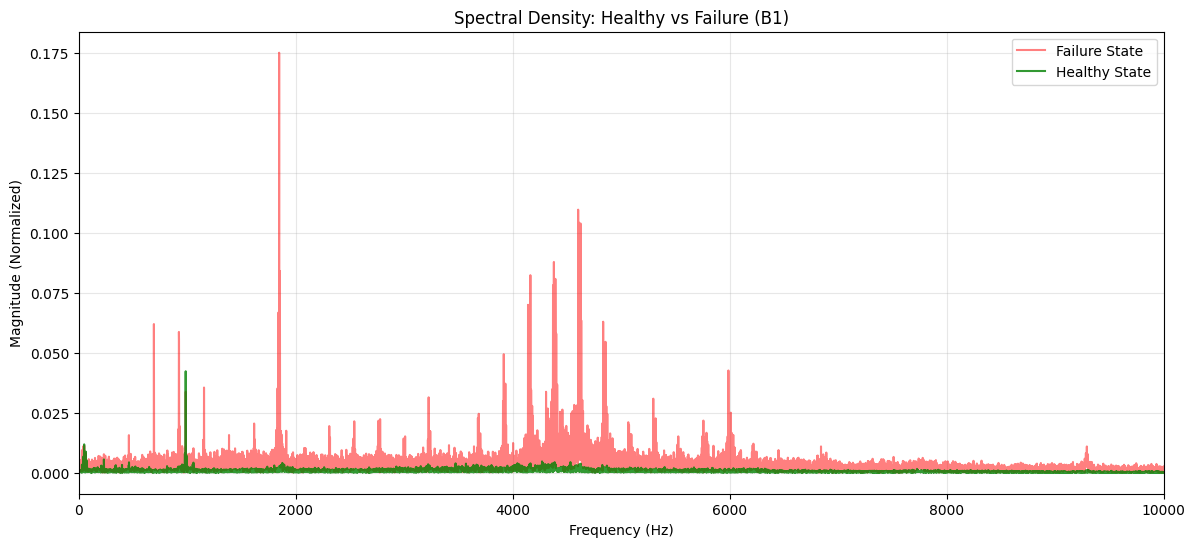

In [ ]:
from scipy.fft import rfft, rfftfreq
import numpy as np

SAMPLING_RATE = 20000

def plot_freq_spectrum(df_healthy, df_broken, bearing_col='B1'):
    n = len(df_healthy)
    xf = rfftfreq(n, d=1/SAMPLING_RATE)

    yf_healthy = np.abs(rfft(df_healthy[bearing_col].values)) / n
    yf_broken = np.abs(rfft(df_broken[bearing_col].values)) / n
    
    # RTTF throws away negative side, half the signal, so we need to double it
    yf_healthy[1:-1] *= 2
    yf_broken[1:-1] *= 2

    # --- Visualization ---
    plt.figure(figsize=(14, 6))
    
    plt.plot(xf, yf_broken, color='red', alpha=0.5, label='Failure State')
    
    plt.plot(xf, yf_healthy, color='green', alpha=0.8, label='Healthy State')
    
    plt.title(f"Spectral Density: Healthy vs Failure ({bearing_col})")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (Normalized)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.xlim(0, 10000)
    
    plt.show()
plot_freq_spectrum(df_healthy, df_broken)